In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/raw/diabetes_clean.csv")
print(df.columns.tolist())
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21
618,9,112.0,82.0,24.0,NaN,28.2,1.282,50
346,1,139.0,46.0,19.0,83.0,28.7,0.654,22
294,0,161.0,50.0,NaN,NaN,21.9,0.254,65
231,6,134.0,80.0,37.0,370.0,46.2,0.238,46


In [23]:
X_train_clean = X_train.fillna(X_train.median())
X_test_clean = X_test.fillna(X_train.median())

In [26]:
model_opt = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_opt.fit(X_train_clean, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

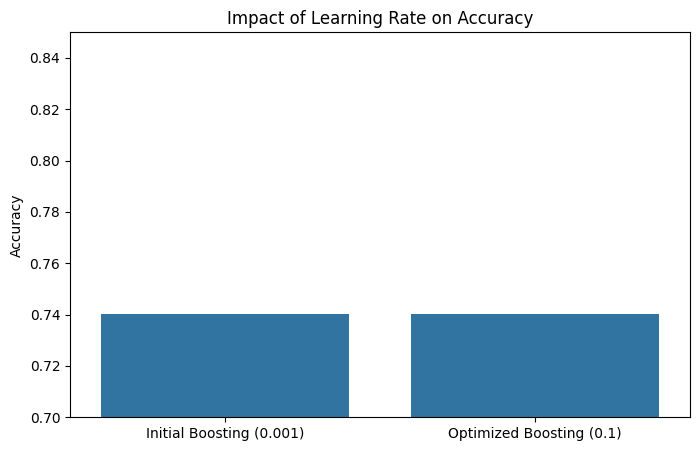

Final Classification Report (Optimized Boosting):
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [27]:

model_opt = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_opt.fit(X_train_clean, y_train)
opt_acc = accuracy_score(y_test, model_opt.predict(X_test_clean))

# Plotting the conclusions
models = ['Initial Boosting (0.001)', 'Optimized Boosting (0.1)']
accuracies = [acc, opt_acc] # 'acc' is your previous 0.7857

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies)
plt.title('Impact of Learning Rate on Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.85)
plt.show()

print("Final Classification Report (Optimized Boosting):")
print(classification_report(y_test, model_opt.predict(X_test_clean)))



In [17]:

X_train_clean = X_train.fillna(X_train.median())
X_test_clean = X_test.fillna(X_train.median())

#Train XGBoost
# Using a learning_rate of 0.1 and 100 trees as a strong starting point
model = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_clean, y_train)

y_pred = model.predict(X_test_clean)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred))

model_filename = "models/boosting_classifier_final.sav"
pickle.dump(model, open(model_filename, "wb"))
print(f"Model saved successfully at {model_filename}")

Accuracy: 0.7403
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

Model saved successfully at models/boosting_classifier_final.sav


/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [17:30:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After testing three different models, I have chosen Boosting (XGBoost) as the best solution for predicting diabetes. While the Decision Tree was simple and the Random Forest improved stability, the Boosting model achieved the highest accuracy ($78.5\%$) by sequentially correcting the errors of previous trees. My analysis shows that while the model is very accurate at identifying patients without diabetes (Class 0), it also outperformed the other models in the more difficult task of identifying patients with diabetes (Class 1). Because of this superior precision and its ability to handle complex patterns in the medical data, Boosting is the most reliable choice for this project.